In [9]:
# For Kaggle — this covers most modern GPUs (T4, P100, A100)
!pip install torch torchvision --index-url https://download.pytorch.org/whl/cu121 -q

In [10]:
!pip install torch-fidelity

In [11]:
import torch
import torchvision
import torch.nn as nn
import torch.nn.functional as F
from torchvision.models import inception_v3
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
from torchvision.utils import make_grid
import matplotlib.pyplot as plt
import numpy as np
from einops import rearrange #pip install einops
from typing import List
import random
import torch_fidelity
import math
from torchvision import datasets, transforms
from timm.utils import ModelEmaV3 #pip install timm 
from tqdm import tqdm #pip install tqdm
import torch.optim as optim
import numpy as np
from typing import Dict, List, Optional, Sequence, Tuple
from scipy.linalg import sqrtm
import os
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from torchvision.models import Inception_V3_Weights

In [12]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [13]:
vae_transform = transforms.Compose([
    transforms.ToTensor(),               
    transforms.Normalize((0.5, 0.5, 0.5), 
                         (0.5, 0.5, 0.5)) 
])

# Fashion-MNIST

In [ ]:

vae_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))   # single-channel mean & std
])

vae_train = torchvision.datasets.FashionMNIST(
    root='/kaggle/working/data', train=True,
    download=True, transform=vae_transform
)
test_set = torchvision.datasets.FashionMNIST(
    root='/kaggle/working/data', train=False,
    download=True, transform=vae_transform
)

classes = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
           'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

Files already downloaded and verified
Files already downloaded and verified


In [16]:
vae_loader = DataLoader(
    vae_train,
    batch_size=64,      
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_set,
    batch_size=64,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)



In [17]:
print(f"Train images: {len(vae_train):,} | Train batches: {len(vae_loader):,}")
print(f"Test images:  {len(test_set):,} | Test batches:  {len(test_loader):,}")

Train images: 60,000 | Train batches: 938
Test images:  10,000 | Test batches:  157


# VAE Functions

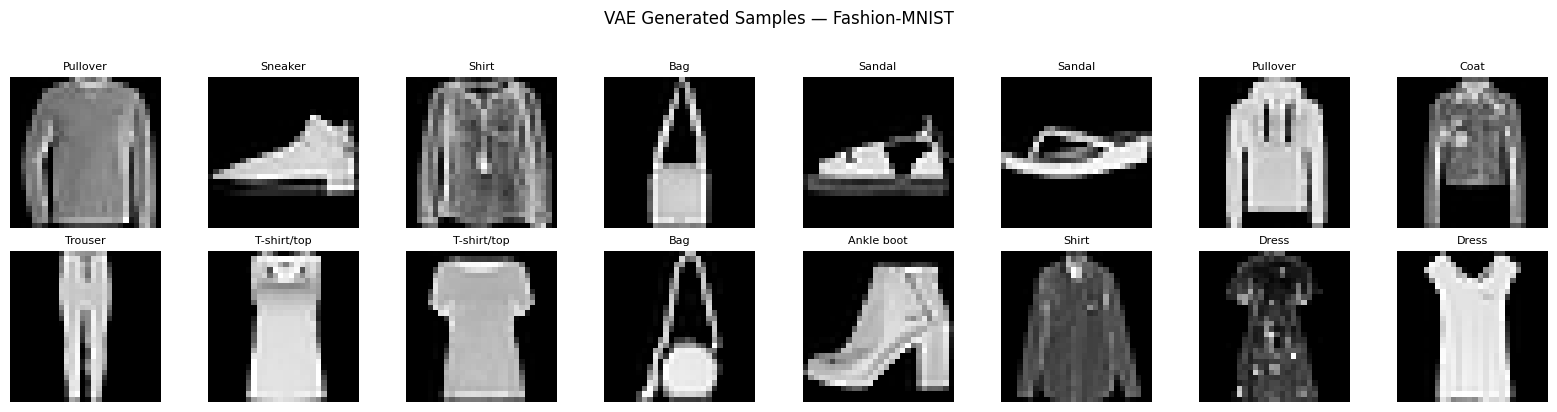

Batch shape : torch.Size([64, 1, 28, 28])
Pixel min   : -1.000
Pixel max   : 1.000


In [18]:

def denormalize(tensor):
    """[-1,1] → [0,1] for visualization"""
    return (tensor * 0.5 + 0.5).clamp(0, 1)

# Grab one batch
images, labels = next(iter(vae_loader))


fig, axes = plt.subplots(2, 8, figsize=(16, 4))
for i, ax in enumerate(axes.flat):
    # img = denormalize(images[i]).permute(1, 2, 0).numpy()
    # ax.imshow(img)
    img = denormalize(images[i]).permute(1, 2, 0).squeeze(-1).numpy()   # (28, 28)
    ax.imshow(img, cmap='gray')
    ax.set_title(classes[labels[i]], fontsize=8)
    ax.axis('off')
# plt.suptitle('CIFAR-10 Sample Batch', y=1.02)
plt.suptitle('VAE Generated Samples — Fashion-MNIST', y=1.02)

plt.tight_layout()
plt.show()

# Check shapes and ranges
print(f"Batch shape : {images.shape}")        # → torch.Size([64, 3, 32, 32])
print(f"Pixel min   : {images.min():.3f}")    # → -1.000
print(f"Pixel max   : {images.max():.3f}")    # → +1.000
# print(f"Dataset size: {len(vae_train)}")      # → 50000

In [ ]:
BATCH_SIZE  = 64
EPOCHS      = 100
LR          = 2e-4
LATENT_DIM  = 128   
BETA        = 1.0   

In [20]:
def set_seed(seed: int = 42):
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    np.random.seed(seed)
    random.seed(seed)

In [ ]:
class ResBlock(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.block = nn.Sequential(
            nn.GroupNorm(8, channels),   
            nn.SiLU(),                   
            nn.Conv2d(channels, channels, kernel_size=3, padding=1),
            nn.GroupNorm(8, channels),
            nn.SiLU(),
            nn.Conv2d(channels, channels, kernel_size=3, padding=1),
        )

    def forward(self, x):
        return x + self.block(x)       

In [ ]:
class Encoder(nn.Module):
    def __init__(self, latent_dim):
        super().__init__()

        self.conv_in = nn.Conv2d(1, 64, kernel_size=3, padding=1)


        self.down1 = nn.Sequential(
            ResBlock(64),
            nn.Conv2d(64, 128, kernel_size=3, stride=2, padding=1), 
        )
        self.down2 = nn.Sequential(
            ResBlock(128),
            nn.Conv2d(128, 256, kernel_size=3, stride=2, padding=1), 
        )

        self.res_mid = ResBlock(256)
    

        self.fc_mu      = nn.Linear(256 * 7 * 7, latent_dim)
        self.fc_log_var = nn.Linear(256 * 7 * 7, latent_dim)

    def forward(self, x):
        x = self.conv_in(x)   
        x = self.down1(x)   
        x = self.down2(x)    
        x = self.res_mid(x)   
        x = x.flatten(1)    

        mu      = self.fc_mu(x)       
        log_var = self.fc_log_var(x) 
        return mu, log_var

In [ ]:
def reparameterize(mu, log_var):
    std     = torch.exp(0.5 * log_var)         
    epsilon = torch.randn_like(std)             
    return mu + std * epsilon                  

In [ ]:
class Decoder(nn.Module):
    def __init__(self, latent_dim):
        super().__init__()

        # self.fc = nn.Linear(latent_dim, 256 * 8 * 8)
        self.fc = nn.Linear(latent_dim, 256 * 7 * 7)
        self.res_in = ResBlock(256)

        self.up1 = nn.Sequential(
            nn.ConvTranspose2d(256, 128, kernel_size=4, stride=2, padding=1), # 8→16
            ResBlock(128),
        )
        self.up2 = nn.Sequential(
            nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1),  # 16→32
            ResBlock(64),
        )

        self.conv_out = nn.Conv2d(64, 1, kernel_size=3, padding=1)

    def forward(self, z):
        x = self.fc(z)                         
        x = x.view(-1, 256, 7, 7)
        x = self.res_in(x)                      
        x = self.up1(x)                       
        x = self.up2(x)                         
        x = self.conv_out(x)                    
        return torch.tanh(x)                   

In [26]:
class VAE(nn.Module):
    def __init__(self, latent_dim=LATENT_DIM):
        super().__init__()
        self.encoder = Encoder(latent_dim)
        self.decoder = Decoder(latent_dim)

    def forward(self, x):
        mu, log_var = self.encoder(x)
        z           = reparameterize(mu, log_var)
        x_hat       = self.decoder(z)
        return x_hat, mu, log_var

    @torch.no_grad()
    def sample(self, n_samples):
        """Generate new images by sampling z from N(0, I)"""
        z = torch.randn(n_samples, LATENT_DIM).to(device)
        return self.decoder(z)

In [27]:
def vae_loss(x, x_hat, mu, log_var, beta=BETA):
    recon_loss = F.mse_loss(x_hat, x, reduction="sum") / x.size(0)
    kl_loss    = -0.5 * torch.mean(
        torch.sum(1 + log_var - mu.pow(2) - log_var.exp(), dim=1)
    )
    return (recon_loss + beta * kl_loss) , recon_loss , kl_loss

In [28]:
def evaluate_vae(model, loader, device):
    model.eval()
    total_loss = 0.0
    with torch.no_grad():
        for x, _ in loader:
            x = x.to(device)
            x_hat, mu, log_var = model(x)
            loss, _, _ = vae_loss(x, x_hat, mu, log_var)
            total_loss += loss.item()
    return total_loss / len(loader)

In [ ]:
def train_vae(
    num_epochs:      int   = 100,
    seed:            int   = -1,
    lr:              float = 2e-4,
    patience:        int   = 7,
    checkpoint_path: str   = None,
):
    set_seed(random.randint(0, 2**32 - 1) if seed == -1 else seed)

    model     = VAE().to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=num_epochs, eta_min=1e-5
    )

    start_epoch = 0
    if checkpoint_path is not None:
        ckpt        = torch.load(checkpoint_path, map_location=device)
        model.load_state_dict(ckpt['weights'])
        optimizer.load_state_dict(ckpt['optimizer'])
        start_epoch = ckpt.get('epoch', 0)
        print(f"Resumed from epoch {start_epoch}.")

    os.makedirs('/kaggle/working/VAE_checkpoints', exist_ok=True)
    best_loss, epochs_no_improve = float('inf'), 0

    for epoch in range(start_epoch, num_epochs):
        model.train()
        total_loss = 0.0

        for x, _ in tqdm(vae_loader, desc=f"Epoch {epoch+1}/{num_epochs}"):
            x = x.to(device)
            optimizer.zero_grad()
            x_hat, mu, log_var  = model(x)
            loss, recon_l, kl_l = vae_loss(x, x_hat, mu, log_var)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            total_loss += loss.item()

        val_loss = evaluate_vae(model, test_loader, device)
        avg_loss = total_loss / len(vae_loader)
        scheduler.step()
        print(f"Epoch {epoch+1} | Train Loss: {avg_loss:.5f} | Val Loss: {val_loss:.5f}")
       
       
        print(f"Epoch {epoch+1}/{num_epochs} | Average Train Loss: {avg_loss:.5f} | "
              f"Recon: {recon_l:.5f} | KL: {kl_l:.5f}")

        if (epoch + 1) % 10 == 0:
            torch.save({
                'weights': model.state_dict(), 'optimizer': optimizer.state_dict(),
                'epoch': epoch + 1, 'loss': avg_loss,
            }, f'/kaggle/working/VAE_checkpoints/vae_cifar10_epoch{epoch+1}.pt')
            print(f"Checkpoint saved at epoch {epoch+1}.")

        if val_loss < best_loss:
            best_loss, epochs_no_improve = val_loss, 0
            torch.save({
                'weights': model.state_dict(), 'optimizer': optimizer.state_dict(),
                'epoch': epoch + 1, 'loss': avg_loss,
            }, '/kaggle/working/VAE_checkpoints/vae_Fashion_MNIST_best.pt')
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                print(f"Early stopping at epoch {epoch+1} "
                      f"(no improvement for {patience} epochs).")
                break

    torch.save({
        'weights': model.state_dict(), 'optimizer': optimizer.state_dict(),
        'epoch': epoch + 1, 'loss': avg_loss,
    }, '/kaggle/working/VAE_checkpoints/vae_Fashion_MNIST_final.pt')
    print("Final checkpoint saved.")
    return model

In [30]:
vae_model = train_vae()

Epoch 1/100: 100%|██████████| 938/938 [00:28<00:00, 32.43it/s]


Epoch 1 | Train Loss: 103.02239 | Val Loss: 82.05353
Epoch 1/100 | Average Train Loss: 103.02239 | Recon: 55.23214 | KL: 22.87334


Epoch 2/100: 100%|██████████| 938/938 [00:28<00:00, 33.05it/s]


Epoch 2 | Train Loss: 75.53728 | Val Loss: 72.25189
Epoch 2/100 | Average Train Loss: 75.53728 | Recon: 52.61545 | KL: 22.56035


Epoch 3/100: 100%|██████████| 938/938 [00:28<00:00, 33.08it/s]


...

Epoch 98 | Train Loss: 49.82044 | Val Loss: 52.69812
Epoch 98/100 | Average Train Loss: 49.82044 | Recon: 23.91173 | KL: 19.46843


Epoch 99/100: 100%|██████████| 938/938 [00:28<00:00, 33.06it/s]


Epoch 99 | Train Loss: 49.81969 | Val Loss: 52.93354
Epoch 99/100 | Average Train Loss: 49.81969 | Recon: 27.26748 | KL: 19.38300


Epoch 100/100: 100%|██████████| 938/938 [00:28<00:00, 33.07it/s]


Epoch 100 | Train Loss: 49.79033 | Val Loss: 52.80529
Epoch 100/100 | Average Train Loss: 49.79033 | Recon: 24.68965 | KL: 18.96920
Checkpoint saved at epoch 100.
Final checkpoint saved.


## Evaluation — FID & Inception Score



In [ ]:
def load_inception(device):
    inception = inception_v3(
         weights=Inception_V3_Weights.DEFAULT,
        transform_input=False).to(device)
    inception.eval()
    return inception


def get_inception_output(imgs, inception, device):
    if imgs.shape[1] == 1:
        imgs = imgs.repeat(1, 3, 1, 1)   # (B, 1, H, W) → (B, 3, H, W)
    imgs = F.interpolate(imgs, size=(299, 299), mode='bilinear', align_corners=False)
    imgs = imgs.to(device)

    features = []
    def hook(m, i, o): features.append(o.squeeze(-1).squeeze(-1))
    handle = inception.avgpool.register_forward_hook(hook)

    with torch.no_grad():
        logits = inception(imgs)
        probs  = F.softmax(logits, dim=1).cpu().numpy()

    handle.remove()
    feats = features[0].cpu().numpy()   
    return feats, probs  

In [32]:
def compute_fid(real_feats, fake_feats):
    mu_r, sigma_r = real_feats.mean(axis=0), np.cov(real_feats, rowvar=False)
    mu_f, sigma_f = fake_feats.mean(axis=0), np.cov(fake_feats, rowvar=False)

    diff = mu_r - mu_f
    covmean, _ = sqrtm(sigma_r @ sigma_f, disp=False)  ## Compute matrix square root
    if np.iscomplexobj(covmean): 
        covmean = covmean.real  ## Take only the real part if result is complex

    return diff @ diff + np.trace(sigma_r + sigma_f - 2 * covmean)

In [33]:
def compute_is(fake_probs):

    p_y = fake_probs.mean(axis=0, keepdims=True)
    kl  = fake_probs * (np.log(fake_probs + 1e-10) - np.log(p_y + 1e-10))
    return float(np.exp(kl.sum(axis=1).mean()))

In [ ]:

N_EVAL   = 10_000   
BATCH_SZ = 64       

inception_model = load_inception(device)

real_feats_all, real_probs_all = [], []

real_eval_dataset = torchvision.datasets.FashionMNIST(
    root='/kaggle/working/data', train=False, download=True,
    transform=transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.5,), (0.5,))
    ])
)
real_eval_loader = DataLoader(real_eval_dataset, batch_size=BATCH_SZ,
                              shuffle=False, num_workers=2)

for imgs, _ in tqdm(real_eval_loader, desc="Real features"):
    # get_inception_output expects [-1,1] input; moves to device internally
    feats, probs = get_inception_output(imgs, inception_model, device)
    real_feats_all.append(feats)
    real_probs_all.append(probs)

real_feats_all = np.concatenate(real_feats_all, axis=0)   # (10000, 2048)

fake_feats_all, fake_probs_all = [], []

vae_model.eval()
n_generated = 0
with torch.no_grad():
    while n_generated < N_EVAL:
        n_batch = min(BATCH_SZ, N_EVAL - n_generated)
        z       = torch.randn(n_batch, LATENT_DIM).to(device)
        imgs    = vae_model.decoder(z)              # (n_batch, 3, 32, 32) in [-1,1]
        feats, probs = get_inception_output(imgs, inception_model, device)
        fake_feats_all.append(feats)
        fake_probs_all.append(probs)
        n_generated += n_batch

fake_feats_all = np.concatenate(fake_feats_all, axis=0)   # (10000, 2048)
fake_probs_all = np.concatenate(fake_probs_all, axis=0)   # (10000, 1000)

fid_score = compute_fid(real_feats_all, fake_feats_all)
is_score  = compute_is(fake_probs_all)

print(f"\nFID             : {fid_score:.2f}  (lower is better)")
print(f"Inception Score : {is_score:.2f}  (higher is better)")

Downloading: "https://download.pytorch.org/models/inception_v3_google-0cc3c7bd.pth" to /root/.cache/torch/hub/checkpoints/inception_v3_google-0cc3c7bd.pth
100%|██████████| 104M/104M [00:00<00:00, 211MB/s]  
Real features: 100%|██████████| 157/157 [00:36<00:00,  4.28it/s]
/tmp/ipykernel_58/546256429.py:6: DeprecationWarning: The `disp` argument is deprecated and will be removed in SciPy 1.18.0.
  covmean, _ = sqrtm(sigma_r @ sigma_f, disp=False)  ## Compute matrix square root



FID             : 46.57  (lower is better)
Inception Score : 3.58  (higher is better)


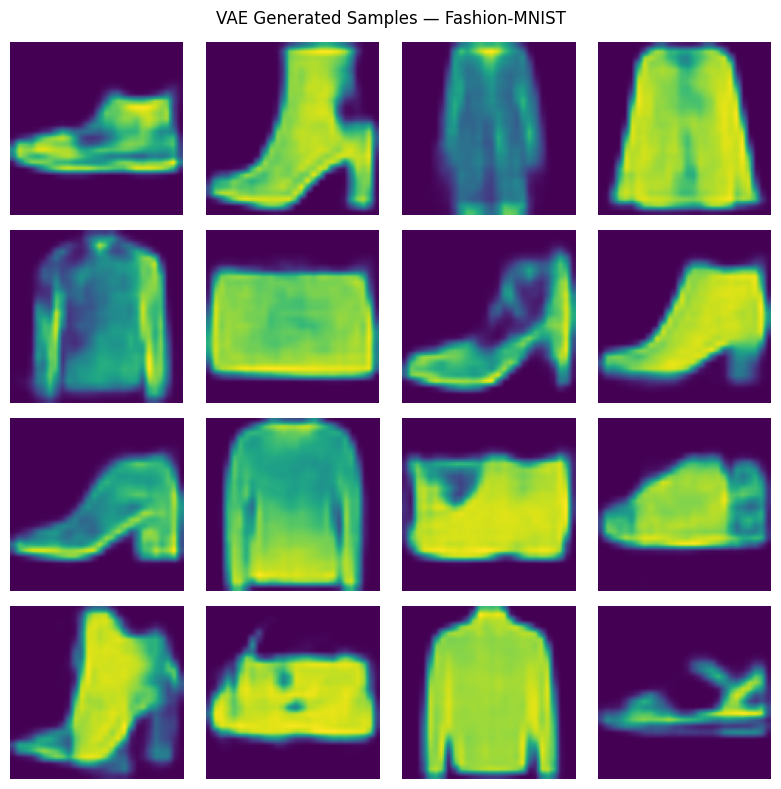

In [ ]:
vae_model.eval()
with torch.no_grad():
    samples = vae_model.sample(16)  

# Upscale for visibility (32→128 px)
# samples = F.interpolate(samples, size=128, mode='bilinear', align_corners=False)
samples = F.interpolate(samples, size=112, mode='bilinear', align_corners=False)

samples = (samples + 1) / 2           # [-1,1] → [0,1]

fig, axes = plt.subplots(4, 4, figsize=(8, 8))
for i, ax in enumerate(axes.flat):
    ax.imshow(samples[i].permute(1, 2, 0).cpu().squeeze(-1).numpy().clip(0, 1))
    ax.axis('off')
plt.suptitle('VAE Generated Samples — Fashion-MNIST')
plt.tight_layout()
plt.savefig('vae_samples.png', dpi=150)
plt.show()

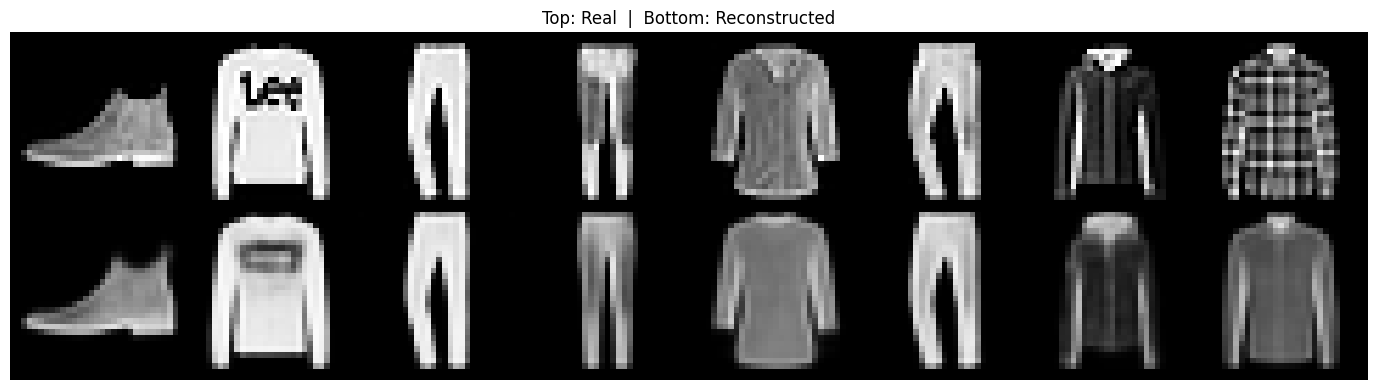

In [ ]:
vae_model.eval()
real_imgs, real_lbls = next(iter(test_loader))
real_imgs = real_imgs[:8].to(device)

with torch.no_grad():
    recon_imgs, _, _ = vae_model(real_imgs)

real_disp  = (real_imgs.cpu()  + 1) / 2
recon_disp = (recon_imgs.cpu() + 1) / 2
comparison = torch.cat([real_disp, recon_disp], dim=0)  # (16, 3, 32, 32)

grid = make_grid(comparison, nrow=8, padding=2)
fig, ax = plt.subplots(figsize=(16, 4))
ax.imshow(grid.permute(1, 2, 0).squeeze(0).numpy(), cmap='gray')
ax.axis('off')
plt.title('Top: Real  |  Bottom: Reconstructed')
plt.tight_layout()
plt.savefig('vae_reconstructions.png', dpi=150)
plt.show()

In [ ]:
def get_latent_space(model, data_loader):
    latent_vectors = []
    model.eval()
    device = next(model.parameters()).device  
    with torch.no_grad():
        for inputs, _ in data_loader:
            inputs = inputs.to(device)        
            mu, log_var = model.encoder(inputs)
            latent_vectors.append(mu.cpu())    
    return torch.cat(latent_vectors, dim=0)
    



Encoding test set: 100%|██████████| 157/157 [00:01<00:00, 88.91it/s]
/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 10000 samples in 0.001s...
[t-SNE] Computed neighbors for 10000 samples in 0.791s...
[t-SNE] Computed conditional probabilities for sample 1000 / 10000
[t-SNE] Computed conditional probabilities for sample 2000 / 10000
[t-SNE] Computed conditional probabilities for sample 3000 / 10000
[t-SNE] Computed conditional probabilities for sample 4000 / 10000
[t-SNE] Computed conditional probabilities for sample 5000 / 10000
[t-SNE] Computed conditional probabilities for sample 6000 / 10000
[t-SNE] Computed conditional probabilities for sample 7000 / 10000
[t-SNE] Computed conditional probabilities for sample 8000 / 10000
[t-SNE] Computed conditional probabilities for sample 9000 / 10000
[t-SNE] Computed conditional probabilities for sample 10000 / 10000
[t-SNE] Mean sigma: 1.085953
[t-SNE] KL divergence after 250 iterations with early exaggeration: 91.812393
[t-SNE] KL divergence after 1000 iterations: 2.241697


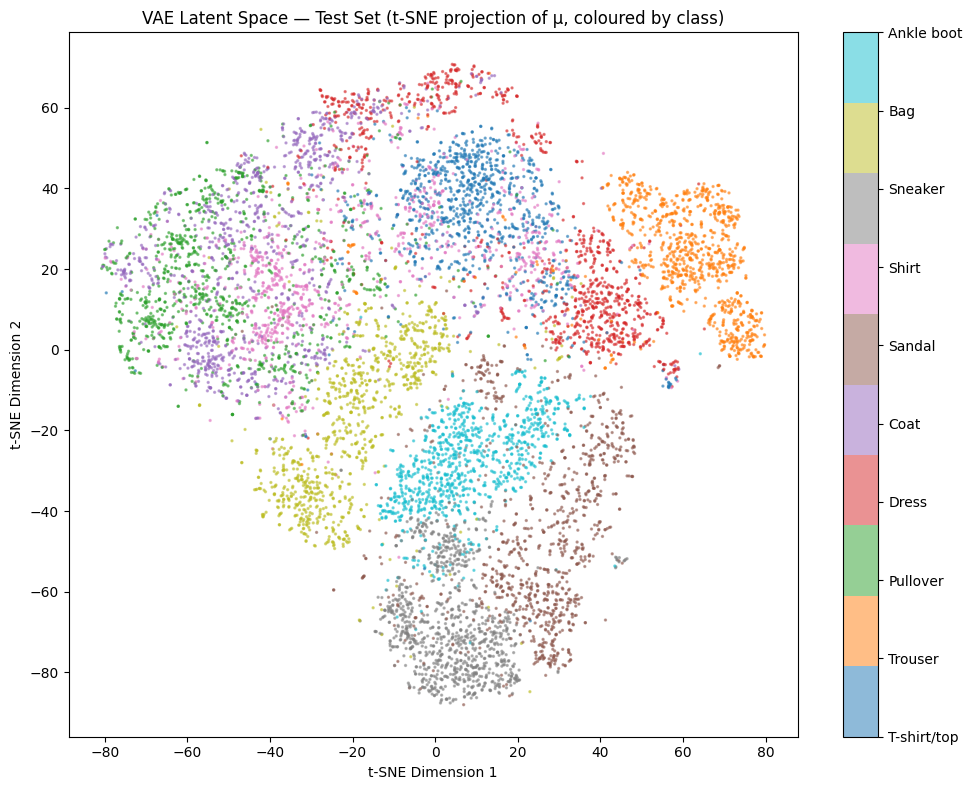

In [ ]:

vae_model.eval()
all_mu, all_labels = [], []
with torch.no_grad():
    for x, labels in tqdm(test_loader, desc="Encoding test set"):
        mu, _ = vae_model.encoder(x.to(device))
        all_mu.append(mu.cpu())
        all_labels.append(labels)
all_mu     = torch.cat(all_mu).numpy()      
all_labels = torch.cat(all_labels).numpy()  

# Project 128-D → 2-D with t-SNE
tsne  = TSNE(n_components=2, perplexity=30, n_iter=1000,
             random_state=42, verbose=1)
mu_2d = tsne.fit_transform(all_mu)          

# Plot
fig, ax = plt.subplots(figsize=(10, 8))
scatter = ax.scatter(
    mu_2d[:, 0], mu_2d[:, 1],
    c=all_labels, cmap='tab10',
    s=2, alpha=0.5
)
cbar = plt.colorbar(scatter, ax=ax, ticks=range(10))
cbar.ax.set_yticklabels(classes)
ax.set_xlabel("t-SNE Dimension 1")
ax.set_ylabel("t-SNE Dimension 2")
ax.set_title("VAE Latent Space — Test Set (t-SNE projection of μ, coloured by class)")
plt.tight_layout()
plt.savefig('vae_latent_tsne.png', dpi=150)
plt.show()

In [ ]:
def plot_latent_space(model, scale=5.0, n=25, digit_size=32, figsize=15):

    model.eval()
    all_mu = []
    with torch.no_grad():
        for x, _ in test_loader:
            mu, _ = model.encoder(x.to(device))
            all_mu.append(mu.cpu())
    all_mu = torch.cat(all_mu).numpy()

    pca = PCA(n_components=2)
    pca.fit(all_mu)

   
    figure = np.zeros((digit_size * n, digit_size * n)) 
    grid_x = np.linspace(-scale, scale, n)
    grid_y = np.linspace(-scale, scale, n)[::-1]

    with torch.no_grad():
        for i, yi in enumerate(grid_y):
            for j, xi in enumerate(grid_x):
                z_128 = pca.inverse_transform([[xi, yi]])
                z_sample = torch.tensor(z_128, dtype=torch.float).to(device)

                x_decoded = model.decoder(z_sample)
        
                digit = (x_decoded[0]
                         .detach().cpu()
                         .reshape(1, digit_size, digit_size)   # → (1, 28, 28)
                         .permute(1, 2, 0)
                         .squeeze(-1))   
                digit = np.clip(digit, 0, 1)       # keep values in [0, 1]
                figure[
                    i * digit_size : (i + 1) * digit_size,
                    j * digit_size : (j + 1) * digit_size,
                ] = digit

    plt.figure(figsize=(figsize, figsize))
    plt.title('VAE Latent Space Visualization')
    start_range = digit_size // 2
    end_range   = n * digit_size + start_range
    pixel_range = np.arange(start_range, end_range, digit_size)
    plt.xticks(pixel_range, np.round(grid_x, 1))
    plt.yticks(pixel_range, np.round(grid_y, 1))
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.imshow(figure, cmap='gray')                            
    plt.show()

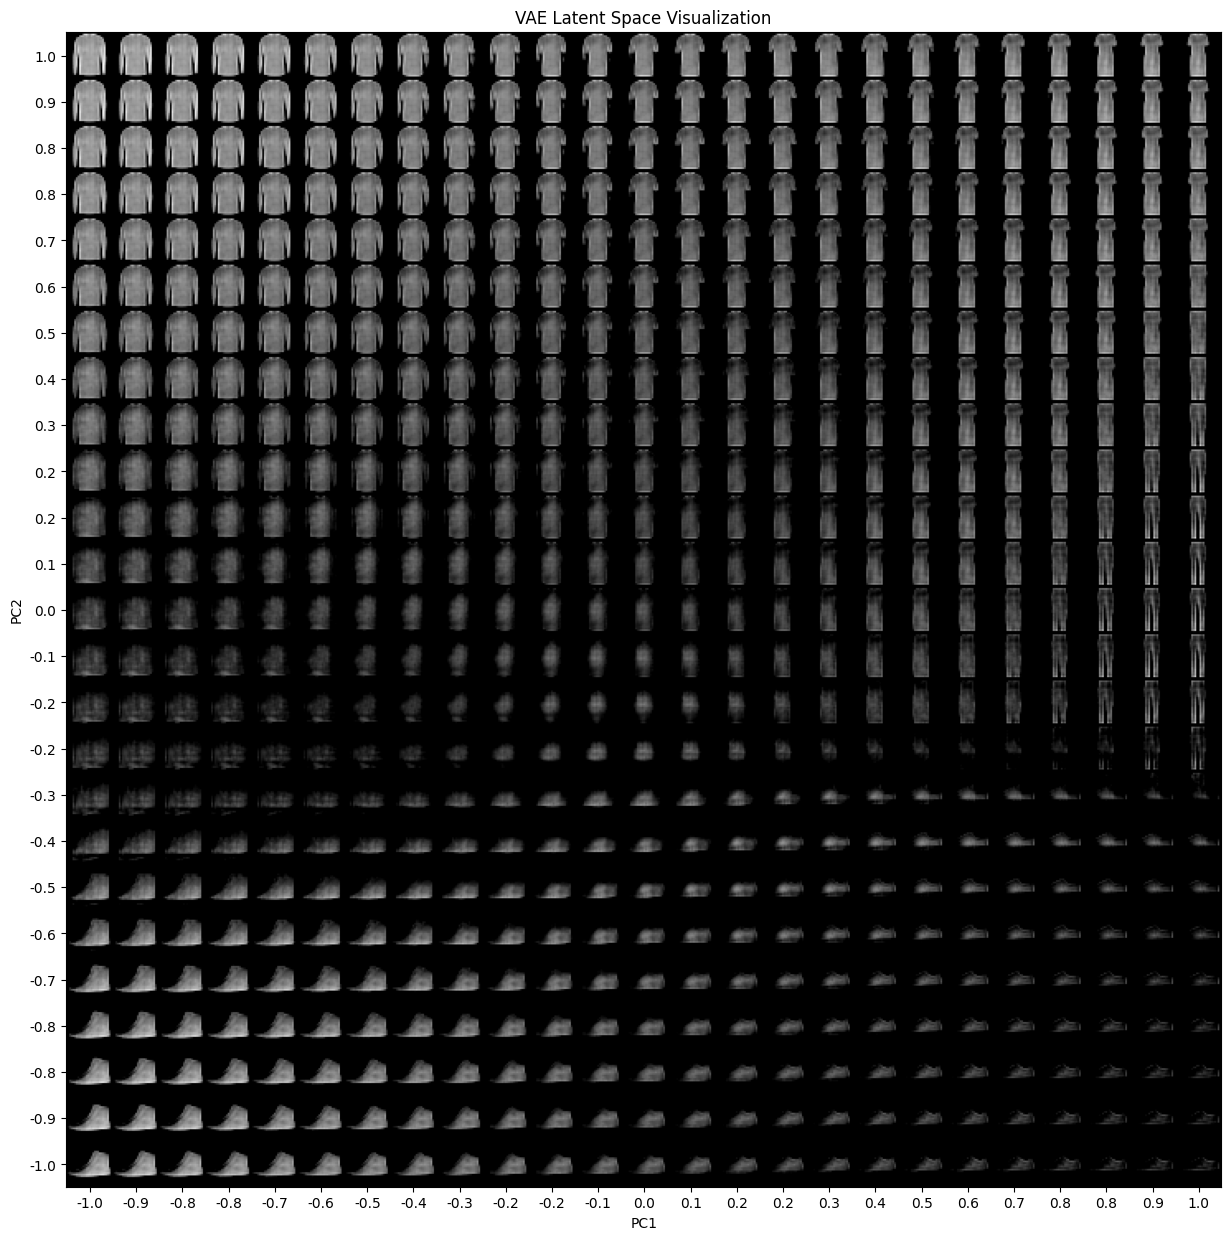

In [50]:
plot_latent_space(vae_model, scale=1.0, digit_size=28)